## Plot of `complete_rows` kernel

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75
_MARKERS = ["o", "^", "s", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}


In [41]:
# Select plot parameters

dtype = "fp32"

In [42]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp32": 4, "fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [46]:
from glob import glob
from os.path import join

df_copy = pd.read_csv(f"../../../bench_results_copy_{dtype}.csv")
df_copy["S"] = "memcopy"
add_stats_siso(df_copy, 4)


df_complete_rows = pd.read_csv(join('..', '..', '..', f"bench_results_complete_rows_{dtype}.csv"))
df_complete_rows["S"] = "Complete-Rows"
add_stats_siso(df_complete_rows, 4)

df_complete_block = pd.read_csv(join('..', '..', '..', f"bench_results_complete_blocks_2_{dtype}.csv"))
df_complete_block["S"] = "Complete-Blocks"
add_stats_siso(df_complete_block, 4)

df = pd.concat([df_copy, df_complete_rows, df_complete_block])

## Paper plots

/tmp/ipykernel_2744293/317099114.py:1: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)


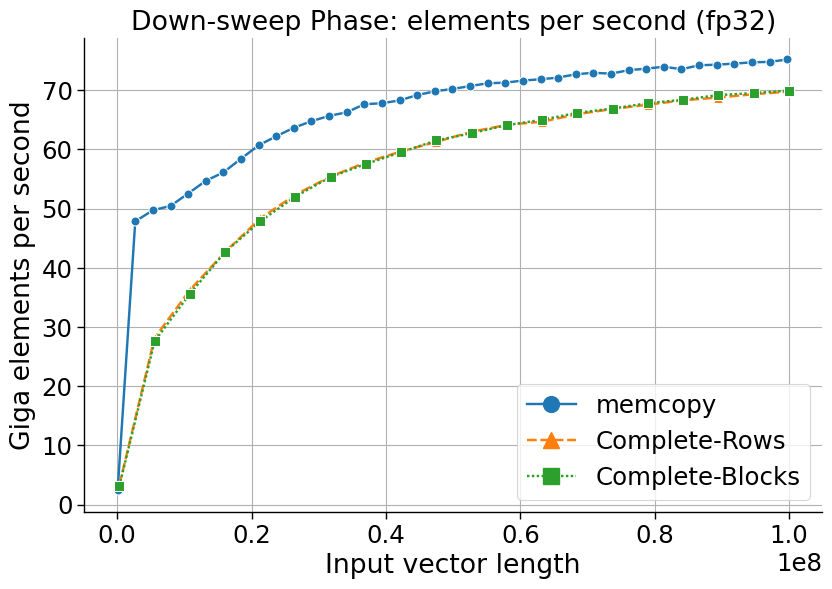

<Figure size 870x627 with 0 Axes>

In [47]:
ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)

ax.set_title(f"Down-sweep Phase: elements per second ({dtype})")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Giga elements per second")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"down_sweep_complete_gelemsps_{dtype}.png")
plt.show()
plt.clf()

/tmp/ipykernel_2744293/1554200322.py:1: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', **_SNS_PARAMS)


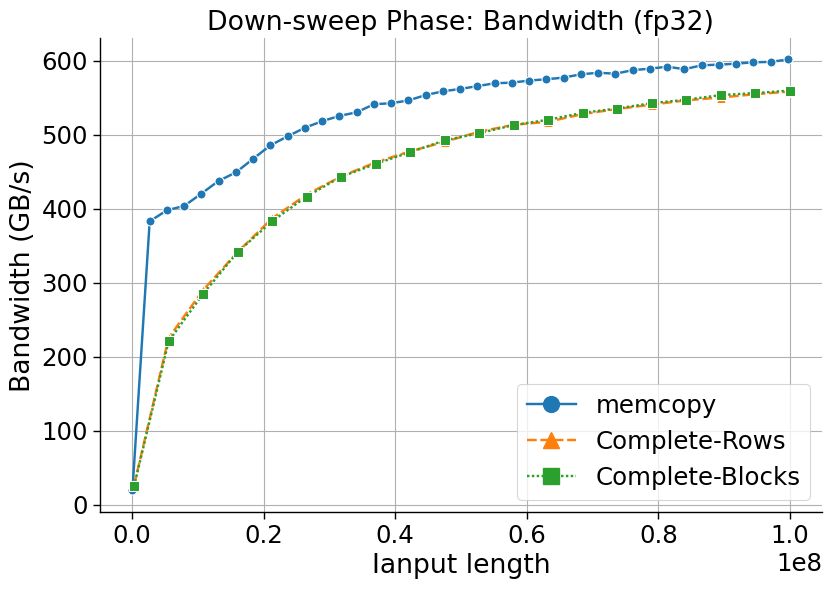

<Figure size 870x627 with 0 Axes>

In [48]:
ax = sns.lineplot(data=df, x='size', y='bw_gbps', **_SNS_PARAMS)

ax.set_title(f"Down-sweep Phase: Bandwidth ({dtype})")
ax.set_xlabel("Ianput length")
ax.set_ylabel("Bandwidth (GB/s)")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"down_sweep_complete_bw_{dtype}.png")
plt.show()
plt.clf()
